# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [1]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=b6d2f069-a853-4d77-81e3-f7e1b45a10dc
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:06<00:00, 65.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=33e9eedc-1cef-4e19-b0db-1273d7c700b4
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:01<00:00, 85.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=62f47498-a04d-45b4-bab2-c89112857fb8
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:01<00:00, 79.8MB/s]


Now lets load the data and visualize the first few examples to see what we are dealing with!

In [2]:
'''
import zipfile
import os
from google.colab import drive

drive.mount('/content/drive')

gdrive_folder = '/content/drive/My Drive/Colab Notebooks'
downloads_folder = "."

train_zip_path = os.path.join(gdrive_folder, "train.zip")
val_zip_path = os.path.join(gdrive_folder, "val.zip")
test_zip_path = os.path.join(gdrive_folder, "test_public.zip")

with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall(downloads_folder)

with zipfile.ZipFile(val_zip_path, 'r') as zip_ref:
    zip_ref.extractall(downloads_folder)

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(downloads_folder)

'''

'\nimport zipfile\nimport os\nfrom google.colab import drive\n\ndrive.mount(\'/content/drive\')\n\ngdrive_folder = \'/content/drive/My Drive/Colab Notebooks\' \ndownloads_folder = "."\n\ntrain_zip_path = os.path.join(gdrive_folder, "train.zip")\nval_zip_path = os.path.join(gdrive_folder, "val.zip")\ntest_zip_path = os.path.join(gdrive_folder, "test_public.zip")\n\nwith zipfile.ZipFile(train_zip_path, \'r\') as zip_ref:\n    zip_ref.extractall(downloads_folder) \n\nwith zipfile.ZipFile(val_zip_path, \'r\') as zip_ref:\n    zip_ref.extractall(downloads_folder)\n\nwith zipfile.ZipFile(test_zip_path, \'r\') as zip_ref:\n    zip_ref.extractall(downloads_folder)\n\n'

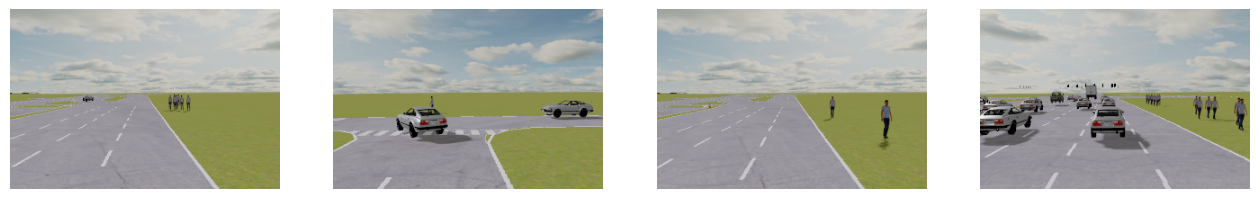

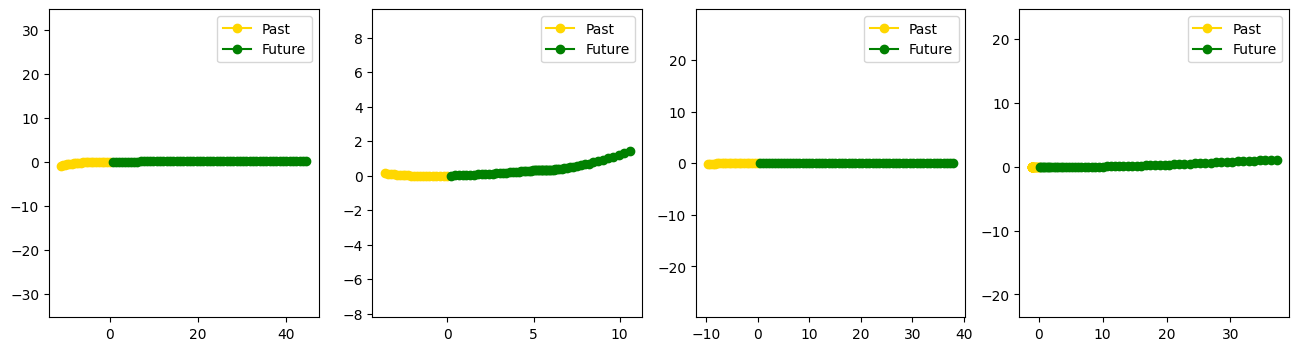

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
# load the data
data = []
for i in random.choices(np.arange(1000), k=k):
    with open(f"train/{i}.pkl", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

In [4]:
import torch
from torch.utils.data import Dataset
import pickle
import torchvision.transforms as transforms
import numpy as np
import random

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, augment=False):
        self.samples = file_list
        self.test = test
        self.augment = augment

        if augment:
            self.transform = transforms.ColorJitter(
                brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05
            )

    def __len__(self):
        return len(self.samples)

    def augment_trajectory(self, history, future=None):
        """Advanced trajectory augmentation"""
        if random.random() < 0.5:
            angle = random.uniform(-15, 15) * (np.pi / 180.0)
            rot_matrix = torch.tensor([
                [np.cos(angle), -np.sin(angle)],
                [np.sin(angle), np.cos(angle)]
            ], dtype=torch.float32)

            history[:, :2] = torch.matmul(history[:, :2], rot_matrix)
            if future is not None:
                future[:, :2] = torch.matmul(future[:, :2], rot_matrix)
                future[:, 2] = future[:, 2] + angle

            history[:, 2] = history[:, 2] + angle

        if random.random() < 0.3:
            noise_scale = 0.02
            history[:, :2] += torch.randn_like(history[:, :2]) * noise_scale
            if future is not None:
                future[:, :2] += torch.randn_like(future[:, :2]) * noise_scale

        if random.random() < 0.3 and future is not None:
            speed_factor = random.uniform(0.9, 1.1)
            last_point = history[-1, :2].clone()
            future[:, :2] = last_point + (future[:, :2] - last_point) * speed_factor

        return history, future

    def __getitem__(self, idx):
        # Load pickle file
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        # Convert numpy arrays to tensors and normalize
        camera = torch.FloatTensor(data['camera']).permute(2, 0, 1) / 255.0
        history = torch.FloatTensor(data['sdc_history_feature'])

        if self.augment and not self.test:
            camera = self.transform(camera)

            if 'driving_command' in data and data['driving_command'] == 'forward':
                if random.random() > 0.5:
                    camera = torch.flip(camera, [2])
                    history[:, 0] = -history[:, 0]
                    history[:, 2] = -history[:, 2]

                    if not self.test:
                        future = torch.FloatTensor(data['sdc_future_feature'])
                        future[:, 0] = -future[:, 0]
                        future[:, 2] = -future[:, 2]
                        return {
                            'camera': camera,
                            'history': history,
                            'future': future
                        }

            if not self.test:
                future = torch.FloatTensor(data['sdc_future_feature'])
                history, future = self.augment_trajectory(history, future)
                return {
                    'camera': camera,
                    'history': history,
                    'future': future
                }

        if not self.test:
            future = torch.FloatTensor(data['sdc_future_feature'])
            return {
                'camera': camera,
                'history': history,
                'future': future
            }
        else:
            return {
                'camera': camera,
                'history': history
            }

In [5]:
class Logger:
    def __init__(self):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        pass

    def log(self, step=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        prefix = f"[Step {step}] " if step is not None else ""
        metric_str = " | ".join(f"{k}: {v}" for k, v in metrics.items())
        # print(prefix + metric_str)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.conv2 = nn.Conv2d(in_channels // 8, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        att = F.relu(self.conv1(x))
        att = self.conv2(att)
        att = self.sigmoid(att)

        out = x * att
        return out

class TemporalWeightedLoss(nn.Module):
    def __init__(self, mode='linear', max_weight=5.0):
        super().__init__()
        self.mode = mode
        self.max_weight = max_weight

    def forward(self, pred, target):
        batch_size, seq_len, feat_dim = pred.size()


        if self.mode == 'linear':

            weights = torch.linspace(1.0, self.max_weight, seq_len).to(pred.device)
        elif self.mode == 'exp':
            weights = torch.exp(torch.linspace(0, np.log(self.max_weight), seq_len)).to(pred.device)

        squared_error = (pred - target)**2
        weighted_error = squared_error * weights.view(1, -1, 1)

        position_error = weighted_error[:, :, :2].mean()

        heading_error = 0.2 * weighted_error[:, :, 2:].mean()

        return position_error + heading_error, position_error, heading_error

class TransformerTrajectoryDecoder(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=512, nhead=8, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = nn.Embedding(100, hidden_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim*2
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, memory, tgt_seq):
        batch_size, seq_len, feat_dim = tgt_seq.size()

        positions = torch.arange(0, seq_len, device=tgt_seq.device)
        positions = positions.unsqueeze(0).repeat(batch_size, 1)
        pos_embeddings = self.pos_encoder(positions)

        tgt_proj = self.input_proj(tgt_seq)

        tgt_proj = tgt_proj + pos_embeddings

        tgt_proj = tgt_proj.permute(1, 0, 2)
        memory = memory.unsqueeze(0)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(tgt_seq.device)

        output = self.transformer_decoder(tgt_proj, memory, tgt_mask=tgt_mask)

        output = output.permute(1, 0, 2)

        return self.output_layer(output)

class DrivingPlanner(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN for processing camera images
        resnet = models.resnet18(pretrained=True)

        self.cnn = nn.Sequential(*list(resnet.children())[:-1])

        self.spatial_attention = SpatialAttention(512)

        self.history_encoder = nn.Sequential(
            nn.Linear(21 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU()
        )

        self.fusion = nn.Sequential(
            nn.Linear(512 + 256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 512),
            nn.ReLU()
        )

        self.transformer_decoder = TransformerTrajectoryDecoder(
            input_dim=3,
            hidden_dim=512,
            nhead=8,
            num_layers=2
        )

    def forward(self, camera, history):
        batch_size = camera.size(0)

        visual_features = self.cnn(camera)
        visual_features = self.spatial_attention(visual_features)
        visual_features = visual_features.view(batch_size, -1)

        history_flat = history.reshape(batch_size, -1)
        history_features = self.history_encoder(history_flat)

        combined = torch.cat([visual_features, history_features], dim=1)
        hidden = self.fusion(combined)

        decoder_input = history[:, -1:, :]

        predictions = [decoder_input]

        for i in range(59):
            current_seq = torch.cat(predictions, dim=1)
            output_seq = self.transformer_decoder(hidden, current_seq)
            next_pred = output_seq[:, -1:, :]
            predictions.append(next_pred)

        return torch.cat(predictions, dim=1)

In [7]:
class TrajectoryLoss(nn.Module):
    def __init__(self, pos_weight=1.0, heading_weight=0.2):
        super().__init__()
        self.pos_weight = pos_weight
        self.heading_weight = heading_weight

    def forward(self, pred, target):
        pos_loss = F.mse_loss(pred[..., :2], target[..., :2])

        heading_loss = F.mse_loss(pred[..., 2:], target[..., 2:])

        total_loss = self.pos_weight * pos_loss + self.heading_weight * heading_loss

        return total_loss, pos_loss, heading_loss

In [8]:
def train(model, train_loader, val_loader, optimizer, logger, num_epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = model.to(device)

    criterion = TemporalWeightedLoss(mode='linear', max_weight=5.0)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True, min_lr=1e-6
    )

    best_ade = float('inf')
    patience = 10
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0

        for idx, batch in enumerate(train_loader):
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            future = batch['future'].to(device)

            optimizer.zero_grad()
            pred_future = model(camera, history)

            loss, pos_loss, heading_loss = criterion(pred_future, future)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            if idx % 10 == 0:
                logger.log(step=epoch * len(train_loader) + idx,
                           loss=loss.item(), pos_loss=pos_loss.item(), heading_loss=heading_loss.item())

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        ade_all, fde_all = [], []

        with torch.no_grad():
            for batch in val_loader:
                camera = batch['camera'].to(device)
                history = batch['history'].to(device)
                future = batch['future'].to(device)

                pred_future = model(camera, history)

                loss, _, _ = criterion(pred_future, future)

                ade = torch.norm(pred_future[:, :, :2] - future[:, :, :2], p=2, dim=-1).mean()
                fde = torch.norm(pred_future[:, -1, :2] - future[:, -1, :2], p=2, dim=-1).mean()

                ade_all.append(ade.item())
                fde_all.append(fde.item())
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_ade = np.mean(ade_all)
        avg_fde = np.mean(fde_all)

        scheduler.step(avg_ade)

        if avg_ade < best_ade:
            best_ade = avg_ade
            torch.save(model.state_dict(), "best_phase1_model.pth")
            patience_counter = 0
            print(f"New best model saved with ADE: {best_ade:.4f}")
        else:
            patience_counter += 1

        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | ADE: {avg_ade:.4f} | FDE: {avg_fde:.4f} | Best ADE: {best_ade:.4f}')

        if patience_counter >= patience:
            print(f"Early stopping after {epoch+1} epochs")
            break

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
val_data_dir = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files = [os.path.join(val_data_dir, f) for f in os.listdir(val_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files, augment=True)
val_dataset = DrivingDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=64, num_workers=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, num_workers=4)

model = DrivingPlanner()

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

logger = Logger()

train(model, train_loader, val_loader, optimizer, logger, num_epochs=100)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNe

Using device: cpu


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


By running the code above, you have trained your first model!
What do you observe in terms of train and val losses? What is this phenomenon called? (Explain in a few lines below)




This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint and also visualize some plans coming from the model. The last cell will provide a `submission_phase1.csv` which you can submit to the leaderboard to see your results on the testing set.

ANS: When training the model, two patterns were observed: firstly, both training loss and validation loss decreased as the model learnt useful parameter from the data. However, after some point, the training loss continued to decreased while validation loss begins to flatten out. Therefore, this phenomena probably refers to overfitting.

In [ ]:
# save the model
torch.save(model.state_dict(), "phase1_model.pth")

In [ ]:
val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
future = val_batch_zero['future'].to(device)

model.eval()
with torch.no_grad():
    pred_future = model(camera, history)

camera = camera.cpu().numpy()
history = history.cpu().numpy()
future = future.cpu().numpy()
pred_future = pred_future.cpu().numpy()
k=4
selected_indices = random.choices(np.arange(len(camera)), k=k)
# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].imshow(camera[idx].transpose(1, 2, 0)/255)
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history[idx, :, 0], history[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future[idx, :, 0], future[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called `submission_phase1.csv` by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [ ]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

In [ ]:
import pandas as pd

test_data_dir = "test_public"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=64, num_workers=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DrivingPlanner()
model.load_state_dict(torch.load("best_phase1_model.pth"))
model.to(device)
model.eval()

all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)

        pred_future = model(camera, history)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
df_xy.to_csv("submission_phase1.csv", index=False)

print("Submission file created successfully!")